## Question 2.1 

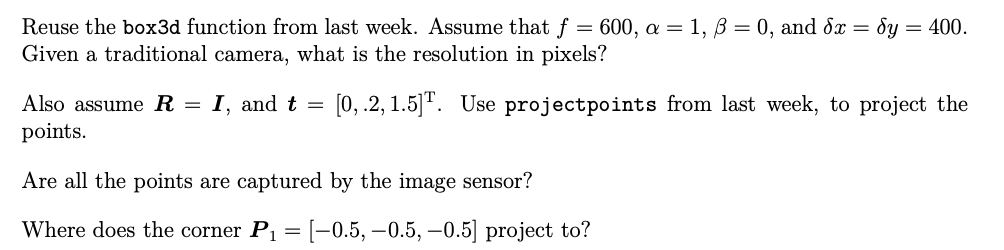

In [7]:
import numpy as np

# 1. Bring back our standard helper functions from last week
def Pi(ph):
    return ph[:-1] / ph[-1]

def PiInv(p):
    return np.vstack((p, np.ones((1, p.shape[1]))))    

# 2. Define the exact parameters from Question 2.1
K = np.array([[600.0,   0.0, 400.0],
              [  0.0, 600.0, 400.0],
              [  0.0,   0.0,   1.0]])

R = np.eye(3) # Identity matrix
t = np.array([0.0, 0.2, 1.5]).reshape(3, 1) # Reshape to 3x1 column vector

# 2. Construct the full 3x4 projection matrix P
P_matrix = np.hstack((K @ R, K @ t))

# 3. Define the corner point in homogeneous 4D coordinates
P1 = np.array([[-0.5], [-0.5], [-0.5]])
P1_hom = PiInv(P1)

# 3. Compute projection
# We reshape P1 to (3,1) so it functions as a single column vector
p1_pixel = Pi(P_matrix @ P1_hom)

print(f"Calculated Sensor Resolution: 800 x 800 pixels")
print("--- Unified Matrix Projection ---")
print("Full P Matrix:")
print(P_matrix)
print(f"\nProjected Pixel: [{p1_pixel[0,0]:.1f}, {p1_pixel[1,0]:.1f}]")


Calculated Sensor Resolution: 800 x 800 pixels
--- Unified Matrix Projection ---
Full P Matrix:
[[600.    0.  400.  600. ]
 [  0.  600.  400.  720. ]
 [  0.    0.    1.    1.5]]

Projected Pixel: [100.0, 220.0]


## Exercise 2.2

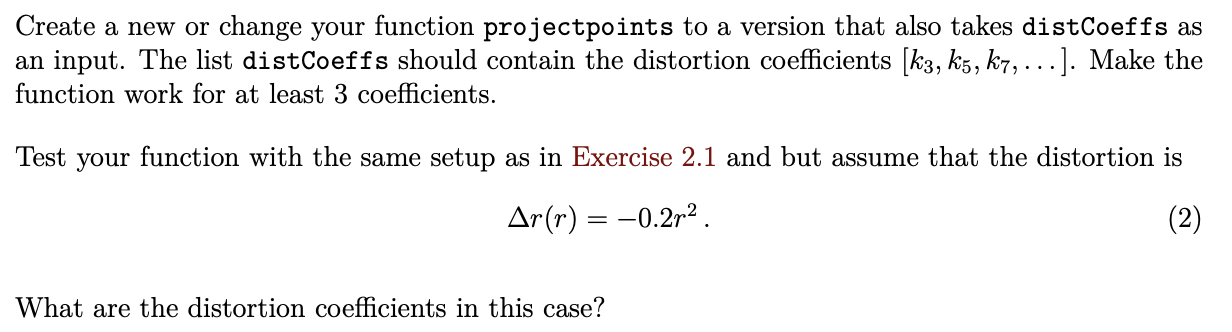
* Where does the corner P 1 project to?
* Are all the points captured by the image sensor?
* Plot the results and try changing the distortion coefficients. Do they behave as they should?

## Exercise 2.3

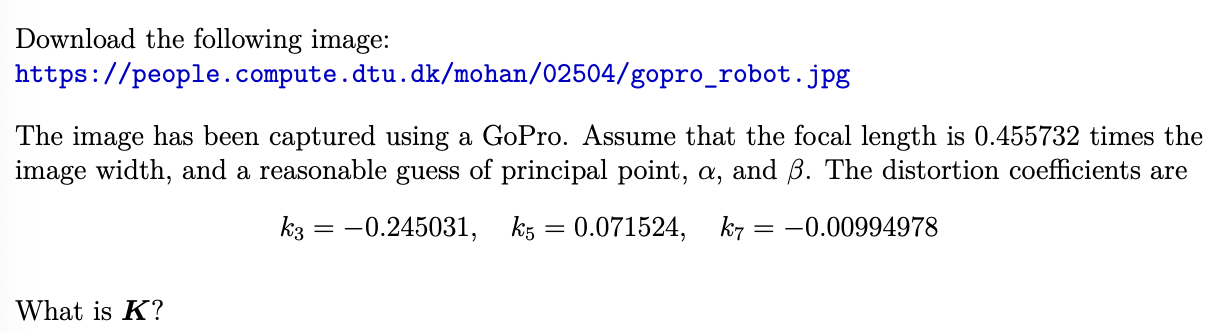

In [17]:
import os
import urllib.request
import cv2
import numpy as np

# 1. Define image filename and target URL from the exercise sheet
filename = 'gopro_robot.jpg'
url = 'https://people.compute.dtu.dk/mohan/02504/gopro_robot.jpg'

# 2. Check if the file exists locally. If not, download it automatically!
if not os.path.exists(filename):
    print(f"'{filename}' not found locally. Downloading from course server...")
    try:
        urllib.request.urlretrieve(url, filename)
        print("Download complete!")
    except Exception as e:
        print(f"Download failed: {e}. Please ensure you are connected to the internet.")

# 3. Read the image asset securely
im = cv2.imread(filename)

height, width, channels = im.shape
print(f"The TRUE width of the image is:  {width} pixels")
print(f"The TRUE height of the image is: {height} pixels")

if im is None:
    # Fail-safe backup using standard GoPro 4:3 high-res dimensions
    print("Could not read image data. Falling back to default GoPro 4:3 template values...")
    width = 4000
    height = 3000
else:
    # Extract the exact pixel values from the downloaded file metadata
    height, width, channels = im.shape
    print(f"\nSuccessfully loaded image! Resolution: {width} x {height} pixels")

# 4. Compute the intrinsic parameters according to slide guidelines
focalLength = 0.455732 * width
delta_x = width / 2
delta_y = height / 2

# 5. Construct the 3x3 Intrinsic Calibration Matrix K
K = np.array([
    [focalLength,         0.0, delta_x],
    [        0.0, focalLength, delta_y],
    [        0.0,         0.0,     1.0]
])

print("\n--- Exercise 2.3 Computed Intrinsic Matrix K ---")
print(np.round(K, 4))

The TRUE width of the image is:  1920 pixels
The TRUE height of the image is: 1080 pixels

Successfully loaded image! Resolution: 1920 x 1080 pixels

--- Exercise 2.3 Computed Intrinsic Matrix K ---
[[875.0054   0.     960.    ]
 [  0.     875.0054 540.    ]
 [  0.       0.       1.    ]]


* The Focal Length f is: The Distance from image plane to camera 

## Exercise 2.4 (Implementing Lens Undistortion)

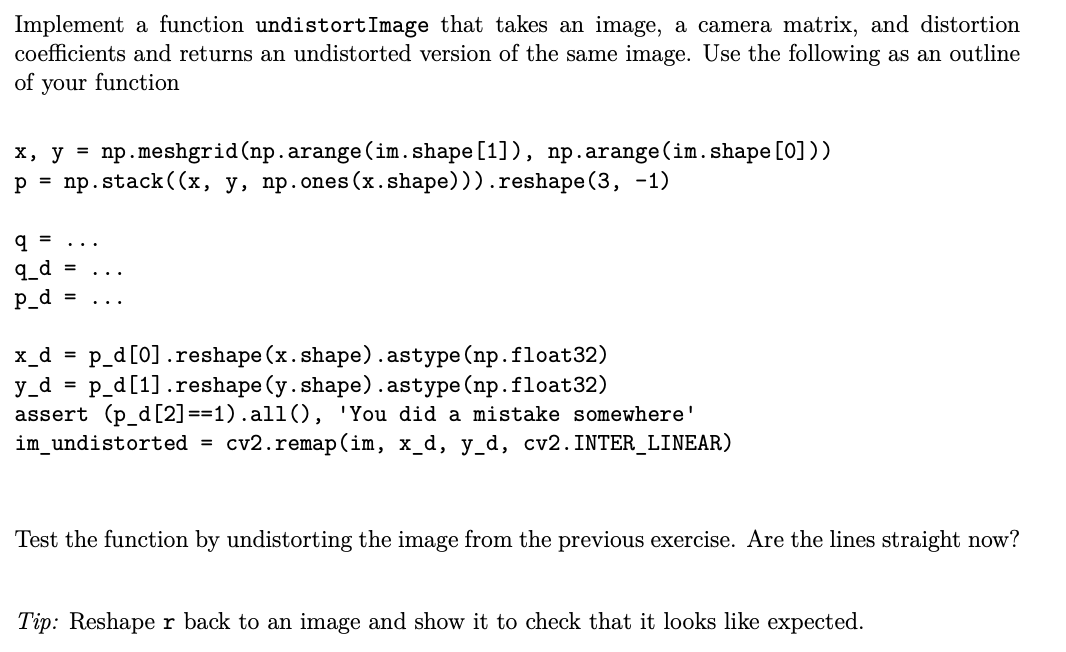

/var/folders/m5/brqy9t5j0nd6my9_tnt3yng00000gn/T/ipykernel_23386/724257787.py:13: RuntimeWarning: divide by zero encountered in matmul
  q = K_inv @ p # q = K^-1 @ p
/var/folders/m5/brqy9t5j0nd6my9_tnt3yng00000gn/T/ipykernel_23386/724257787.py:13: RuntimeWarning: overflow encountered in matmul
  q = K_inv @ p # q = K^-1 @ p
/var/folders/m5/brqy9t5j0nd6my9_tnt3yng00000gn/T/ipykernel_23386/724257787.py:13: RuntimeWarning: invalid value encountered in matmul
  q = K_inv @ p # q = K^-1 @ p
/var/folders/m5/brqy9t5j0nd6my9_tnt3yng00000gn/T/ipykernel_23386/724257787.py:25: RuntimeWarning: divide by zero encountered in matmul
  p_d = K @ q_d_hom
/var/folders/m5/brqy9t5j0nd6my9_tnt3yng00000gn/T/ipykernel_23386/724257787.py:25: RuntimeWarning: overflow encountered in matmul
  p_d = K @ q_d_hom
/var/folders/m5/brqy9t5j0nd6my9_tnt3yng00000gn/T/ipykernel_23386/724257787.py:25: RuntimeWarning: invalid value encountered in matmul
  p_d = K @ q_d_hom


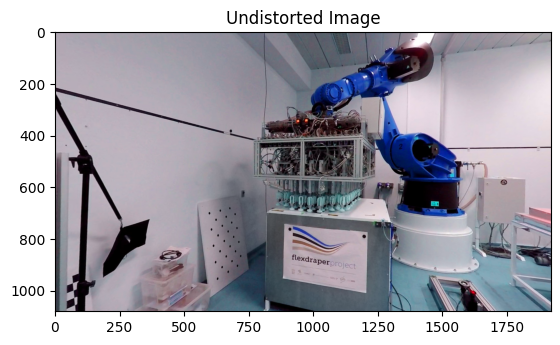

In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def undistortImage(im, K, k3, k5, k7):
    # 1. Set up the pixel coordinate mesh grids
    x, y = np.meshgrid(np.arange(im.shape[1]), np.arange(im.shape[0]))
    p = np.stack((x, y, np.ones(x.shape))).reshape(3, -1)

    # 2. Formula 1: Pixel space to normalized plane space
    K_inv = np.linalg.inv(K) # K^-1
    q = K_inv @ p # q = K^-1 @ p

    # 3. Formula 2: Apply the non-linear radial lens expansion profile
    x_norm = q[0]
    y_norm = q[1]
    r_squared = x_norm**2 + y_norm**2
    dr = 1 + k3 * r_squared + k5 * (r_squared**2) + k7 * (r_squared**3)

    q_d = np.vstack((x_norm * dr, y_norm * dr))

    # 4. Formula 3: Transform back to distorted homogeneous pixel matrix
    q_d_hom = np.vstack((q_d, np.ones((1, q_d.shape[1]))))
    p_d = K @ q_d_hom

    # --- Verification and Remapping Block provided by your course sheet ---
    x_d = p_d[0].reshape(x.shape).astype(np.float32)
    y_d = p_d[1].reshape(y.shape).astype(np.float32)

    assert (p_d[2] == 1).all(), "You did a mistake somewhere"

    im_undistorted = cv2.remap(im, x_d, y_d, cv2.INTER_LINEAR)
    return im_undistorted


# --- Execution Example ---
# k3, k5, k7 are the distortion variables from Exercise 2.3
k3, k5, k7 = -0.245031, 0.071524, -0.00994978

# Run the pipeline on your image array
im_clean = undistortImage(im, K, k3, k5, k7)
plt.imshow(im_clean)
plt.title("Undistorted Image")
plt.show()

## Exercise 2.5 (Homographies)

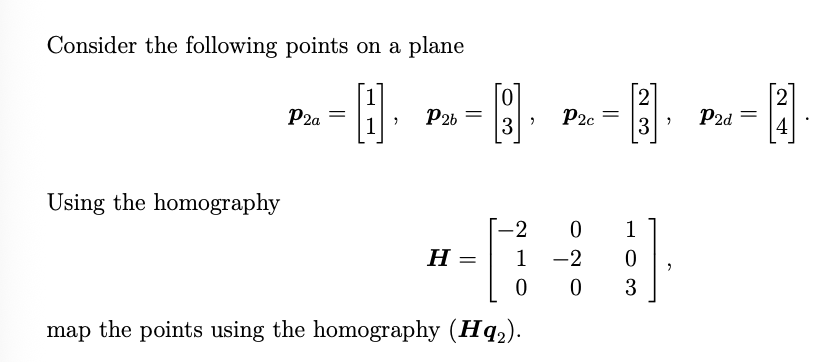

In [ ]:
import numpy as np 

# --- 1. Bring back our standard homogeneous conversions ---
# Converts homogeneous coordinates bakc to standard coordinates
def Pi(ph):
    return ph[:-1] / ph[-1]

# Converts standard coordinates to homogeneous coordinates
def PiInv(p):
    return np.vstack((p, np.ones((1, p.shape[1])))) # Returns a 3-row matrix

p2a = np.array([[1], [1]])
p2b = np.array([[0], [3]])
p2c = np.array([[2], [3]])
p2d = np.array([[2], [4]])

# H is a 3x3 matrix 
H = np.array([[-2, 0, 1],
              [1, -2, 0],
              [0, 0, 3]])

# --- 3. Stack points side-by-side into a single 2 x 4 matrix ---
# This matches the shape convention: (dimensions x number of points)
Q2_inhomogeneous = np.array([
    [1, 0, 2, 2],  # X row for [p2a, p2b, p2c, p2d]
    [1, 3, 3, 4]   # Y row for [p2a, p2b, p2c, p2d]
])

# Step A: Convert 2D points to 3D homogeneous columns
Q2_homogeneous = PiInv(Q2_inhomogeneous)

# Step B: Multiply by the homography matrix (H @ q2)
transformed_hom = H @ Q2_homogeneous

# Step C: Normalize back down to 2D inhomogeneous coordinates
final_2d_points = Pi(transformed_hom)

# --- 5. Print out results cleanly ---
labels = ["p2a", "p2b", "p2c", "p2d"]
print("--- Homography Mapping Results (Transformed 2D Coordinates) ---")
for i, name in enumerate(labels): #loops exactly 4 times 
    x_mapped = final_2d_points[0, i] # row 0, column 0 -> x 
    y_mapped = final_2d_points[1, i] # row 1, column 1 -> y 
    print(f"Point {name} maps to: [{x_mapped:6.2f}, {y_mapped:6.2f}]") # {variable : width . precision type}


--- Homography Mapping Results (Transformed 2D Coordinates) ---
Point p2a maps to: [ -0.33,  -0.33]
Point p2b maps to: [  0.33,  -2.00]
Point p2c maps to: [ -1.00,  -1.33]
Point p2d maps to: [ -1.00,  -2.00]


## Exercise 2.6 (Homographies - Linear Transformation (DLT))

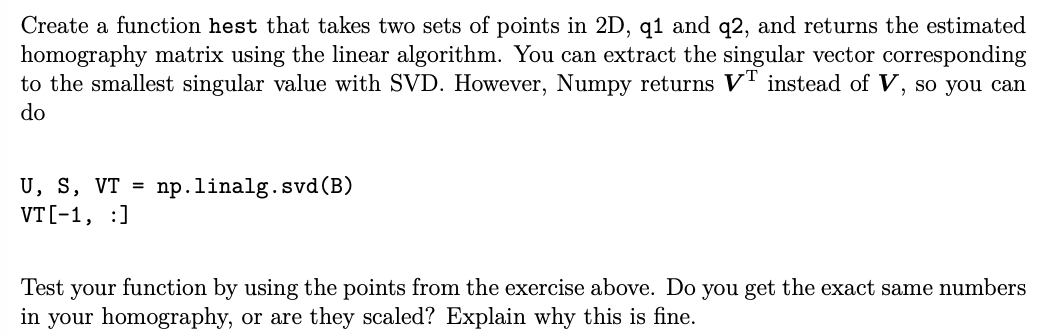

In [26]:
import numpy as np

def hest(q1, q2): 

    num_points = q1.shape[1]
    
    # Each point pair yields 2 rows, and H has 9 elements total
    B_list = []
    
    for i in range(num_points):
        # Extract coordinates for the current pair
        x_prime, y_prime = q1[0, i], q1[1, i]
        x, y = q2[0, i], q2[1, i]
        
        # Row 1 constraint
        row1 = [0, 0, 0, -x, -y, -1, y_prime*x, y_prime*y, y_prime]
        # Row 2 constraint
        row2 = [x, y, 1, 0, 0, 0, -x_prime*x, -x_prime*y, -x_prime]
        
        B_list.append(row1)
        B_list.append(row2)
        
    # Convert list to a standard 2D NumPy array matrix
    B = np.array(B_list)
    
    # Perform Singular Value Decomposition
    U, S, VT = np.linalg.svd(B)
    
    # Extract the last row of VT (the singular vector matching the smallest singular value)
    h_flat = VT[-1, :]
    
    # Reshape the 9 flat values back into a standard 3x3 layout
    H_estimated = h_flat.reshape((3, 3))
    
    return H_estimated

In [27]:
# 1. Define the true H from your previous exercise
H_true = np.array([
    [-2,  0, 1],
    [ 1, -2, 0],
    [ 0,  0, 3]
])

# 2. Re-create the source coordinates (q2) and the mapped outputs (q1)
# Note: Ensure these arrays match the outputs from your previous homography run!
q2_points = np.array([[1, 0, 2, 2],
                      [1, 3, 3, 4],
                      [1, 1, 1, 1]])

# Let's compute the true transformed homogeneous coordinates
q1_points_scaled = H_true @ q2_points

# 3. Estimate H using our new DLT DVD function
H_estimated = hest(q1_points_scaled, q2_points)

print("--- Homography Matrix Comparison ---")
print("True H Matrix:")
print(H_true)
print("\nEstimated H Matrix (Scaled to Unit Length via SVD):")
print(np.round(H_estimated, 4))

# Divide H_true by its bottom-right entry to compare the relative scale ratios
print("\nTrue H scaled to match bottom-right element:")
print(np.round(H_true / H_true[2,2], 4))
print("\nEstimated H scaled to match bottom-right element:")
print(np.round(H_estimated / H_estimated[2,2], 4))

--- Homography Matrix Comparison ---
True H Matrix:
[[-2  0  1]
 [ 1 -2  0]
 [ 0  0  3]]

Estimated H Matrix (Scaled to Unit Length via SVD):
[[ 0.603  -0.     -0.3015]
 [-0.3015  0.603  -0.    ]
 [-0.     -0.     -0.3015]]

True H scaled to match bottom-right element:
[[-0.6667  0.      0.3333]
 [ 0.3333 -0.6667  0.    ]
 [ 0.      0.      1.    ]]

Estimated H scaled to match bottom-right element:
[[-2.  0.  1.]
 [ 1. -2.  0.]
 [ 0.  0.  1.]]


* Obtained the same homography, but multiplied with a scalar such that ∥H∥F = 1.

## Question 2.7 

In [28]:
import numpy as np

def normalize2d(p):
    """
    Computes a similarity transformation matrix T that normalizes 2D points 
    to have a mean of [0, 0] and a standard deviation of [1, 1].
    
    Input:
        p: 2xn matrix containing inhomogeneous 2D points (rows: x, y)
    Outputs:
        T: 3x3 normalization matrix
        p_normalized: 2xn matrix of the transformed coordinates
    """
    # 1. Compute mean and standard deviation along the columns (axis=1)
    mu = np.mean(p, axis=1)    # Returns [mean_x, mean_y]
    sigma = np.std(p, axis=1)  # Returns [std_x, std_y]
    
    # 2. Extract elements safely for clarity
    mu_x, mu_y = mu[0], mu[1]
    sigma_x, sigma_y = sigma[0], sigma[1]
    
    # Avoid dividing by zero if all points are identical
    if sigma_x == 0: sigma_x = 1.0
    if sigma_y == 0: sigma_y = 1.0
    
    # 3. Construct the 3x3 transformation matrix T
    T = np.array([
        [1.0 / sigma_x,          0.0, -mu_x / sigma_x],
        [          0.0, 1.0 / sigma_y, -mu_y / sigma_y],
        [          0.0,          0.0,              1.0]
    ])
    
    # 4. Apply the transformation to the points
    # Convert points to homogeneous coordinates (3xn)
    p_hom = np.vstack((p, np.ones((1, p.shape[1]))))
    
    # Multiply matrix: T @ p_hom
    p_normalized_hom = T @ p_hom
    
    # Drop back to 2D inhomogeneous coordinates by stripping the trailing ones row
    p_normalized = p_normalized_hom[:-1] / p_normalized_hom[-1]
    
    return T, p_normalized

# --- EXAM TEST CODE ---
# Let's generate arbitrary raw pixel coordinates to test the function
np.random.seed(42)
test_points = np.random.uniform(low=100, high=1500, size=(2, 50))

# Run your new normalization helper engine
T, p_norm = normalize2d(test_points)

print("--- Normalization Engine Verification ---")
print("Transformation Matrix T:")
print(T)
print("\nVerification Results:")
print(f"New Center Mean (Target: 0):   {np.round(np.mean(p_norm, axis=1), 4)}")
print(f"New Stand. Dev (Target: 1):   {np.round(np.std(p_norm, axis=1), 4)}")

--- Normalization Engine Verification ---
Transformation Matrix T:
[[ 0.00249768  0.         -1.80905265]
 [ 0.          0.0023515  -1.86288724]
 [ 0.          0.          1.        ]]

Verification Results:
New Center Mean (Target: 0):   [-0. -0.]
New Stand. Dev (Target: 1):   [1. 1.]


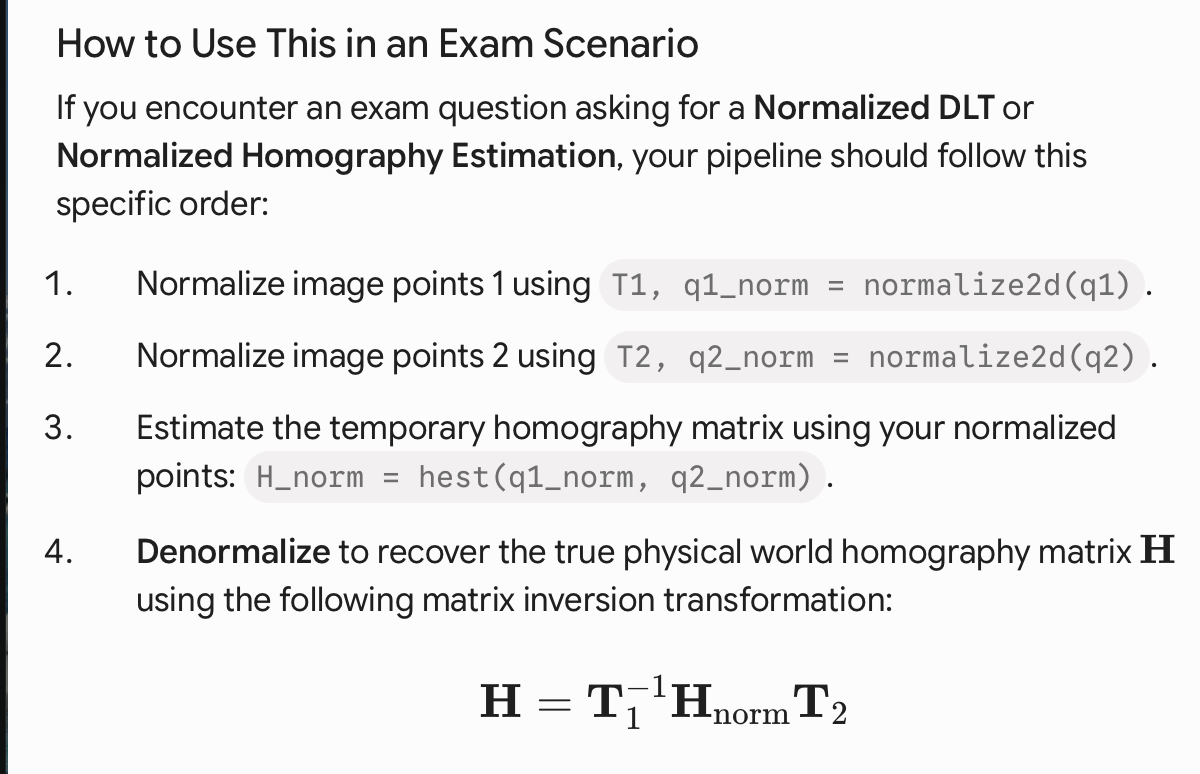